## 1. Load and inspect the dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# Load the dataset
wine = load_wine(as_frame=True)

df = wine.frame

# Display the first 5 rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [9]:
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

1. How many samples are in the dataset? 178
2. How many features does each sample contain? 13
3. How many classes are present? 3
4. Are the features measured on the same scale? 
No. The selected features have substantially different numerical ranges. For example, proline ranges from around 278 to 1680 and magnesium is from 100 to 127. The standard variance for these 2 are noticeably higher than the rest of the variables. This would affect the PCA model as it would dominate the model.

## 2. Standardize the features

In [7]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [6]:
# Separate features and target
X = df.drop(columns = "target")
y = df["target"]

# Standardize: each feature gets mean 0 and standard deviation 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(pd.DataFrame(X_scaled, columns = X.columns).describe().loc[["mean", "std"]].round(2))

      alcohol  malic_acid  ash  alcalinity_of_ash  magnesium  total_phenols  \
mean     -0.0        -0.0 -0.0               -0.0       -0.0            0.0   
std       1.0         1.0  1.0                1.0        1.0            1.0   

      flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity  hue  \
mean        -0.0                   0.0             -0.0              0.0  0.0   
std          1.0                   1.0              1.0              1.0  1.0   

      od280/od315_of_diluted_wines  proline  
mean                           0.0     -0.0  
std                            1.0      1.0  


Question: Explain why standardization is particularly important before applying PCA to this dataset?

PCA looks for the directions in which the data varies the most. Variance depends on the scale and units of each feature, so without standardization, features with large numeric values will dominate the principal components.

For example, in the wine dataset, Proline has a standard deviation of 314.91 (2dp) and has a mean of 746.89 (2dp), while hue has a standard deviation of 0.23 (2dp) and a mean of 0.96 (2dp). Proline's variance is way larger than that of the smaller features. Hence, without standard deviation, the first principal component would almost entirely follow proline, and the result would mostly reflect its measurement units rather than the real structure of the data. The other features would have almost no influence. 

Standardization rescales each feature to a mean of 0 and standard deviation of 1. Every feature then starts on equal footing, and PCA finds directions based on how the features vary together. This matters especially here because the features are different kinds of quantities, such as alcohol percentage, concentrations, and color intensity, with no common unit to compare them.

## 3. Apply PCA

In [ ]:
pca = PCA(n_components=2)
pca.fit(X_scaled)

Questions
1. Can you visually distinguish the three wine classes?
2. Are some classes more clearly separated than others?
3. What does each point in the PCA plot represent?
4. What information may have been lost by reducing 13 dimensions to 2?

## 4. Explained variance

In [12]:
# Perform PCA using all components
pca_all = PCA()
X_pca_all = pca_all.fit_transform(X_scaled)

# Explained variance ratio of each principal component
explained_variance = pca_all.explained_variance_ratio_

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

print("Explained variance ratio:")
print(explained_variance)

print("\nCumulative explained variance:")
print(cumulative_variance)

Explained variance ratio:
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]

Cumulative explained variance:
[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


/Users/najaandriamumtaz/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/najaandriamumtaz/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/najaandriamumtaz/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


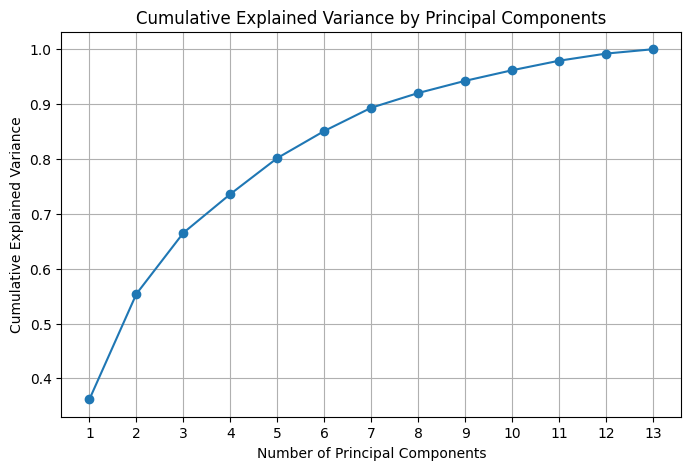

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by Principal Components")

plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid()

plt.show()

Questions
1. How much variance is explained by the first two components?
2. How many components are required to explain at least 80% of the variance?
3. How many are required for at least 90%?
4. Why might we want to use fewer dimensions even if some information is lost?

In [19]:
variance_first_two = cumulative_variance[1]

components_80 = np.argmax(cumulative_variance >= 0.80) + 1
components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(
    components_80
)

print(
    components_90

)


5
8


Answers
1. Variance explained by first two components: 55.41 %
2. Components required for at least 80% variance: 5
3. Components required for at least 90% variance: 8
4. We want to use fewer dimensions because it makes the data faster to process and easier to visualize. Reducing the number of dimensions can also remove redundant information while still keeping most of the useful variation in the dataset. Although some information is lost, the reduced dataset can still preserve the main patterns while making further analysis more efficient.